# Overfitting minimal set of intervals

## imports

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

PAL_MODALITIES = {
    "rna_seq": "#717EC3",
    "splice_site": "#AE8799",
    "splice_usage": "#C95D63",
    "splice_junctions": "#EE8434"
}

MAP_MODALITIES = {
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_pearson_r":"splice_junctions"
}

OUTPUT_DIR = os.path.join("pdfs","overfitting_dev")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## data

In [ ]:
# paths

ROOT = ".."
RESULTS_DIR = os.path.join(ROOT,"results")
OUTPUT_DIR = os.path.join(ROOT,"results/bsc/finetuning/alphagenome_pytorch/full")
logs_file = os.path.join(OUTPUT_DIR, "summary", "epoch_logs.parquet")

EVAL_DIR = os.path.join(RESULTS_DIR,"bsc","evaluation","alphagenome_pytorch","full")
RUNS_OI = ["randinit__newloss__annotated__frozen__multigpu_ddp"]
EPOCHS_OI = [5, 10, 15, 20]

PREDS_DIR = os.path.join(EVAL_DIR, RUNS_OI[0], "epoch20", "predictions")
pred_files = {
    "rna_seq_per_gene": os.path.join(PREDS_DIR,"rna_seq_per_gene.parquet"),
    "splice_site_scores": os.path.join(PREDS_DIR,"splice_site_scores.parquet"),
    "ssu_scores": os.path.join(PREDS_DIR,"ssu_scores.parquet"),
    "junction_totals": os.path.join(PREDS_DIR,"junction_totals.parquet"),
    "junction_scores": os.path.join(PREDS_DIR,"junction_scores.parquet"),
    "psi_scores": os.path.join(PREDS_DIR,"psi_scores.parquet"),
}

In [ ]:
# loads

logs = pd.read_parquet(logs_file)
preds = {k: pd.read_parquet(f) for k, f in pred_files.items()}
# Load metrics across epochs
metrics_epochs = []
for run_name in RUNS_OI:
    for epoch in EPOCHS_OI:
        fpath = os.path.join(EVAL_DIR, run_name, "epoch{}".format(epoch), "metrics.parquet")
        if os.path.exists(fpath):
            df = pd.read_parquet(fpath)
            df["run_name"] = run_name
            df["epoch"] = epoch
            metrics_epochs.append(df)
metrics_epochs = pd.concat(metrics_epochs, ignore_index=True)

## figures

### evaluation metrics

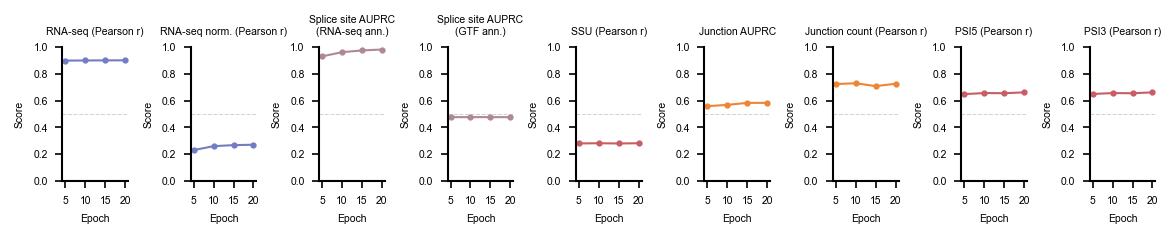

In [4]:
METRICS_OI = [
    "gene_expr_raw_mean",
    "gene_expr_norm_across_genes_mean",
    "splice_site_auprc_macro_rnaseq",
    "splice_site_auprc_macro_gtf",
    "ssu_pearson_r_mean",
    "junction_auprc_mean",
    "junction_count_pearson_r_mean",
    "psi5_pearson_r_mean",
    "psi3_pearson_r_mean",
]

MAP_LABELS = {
    "gene_expr_raw_mean": "RNA-seq (Pearson r)",
    "gene_expr_norm_across_genes_mean": "RNA-seq norm. (Pearson r)",
    "splice_site_auprc_macro_rnaseq": "Splice site AUPRC\n(RNA-seq ann.)",
    "splice_site_auprc_macro_gtf": "Splice site AUPRC\n(GTF ann.)",
    "ssu_pearson_r_mean": "SSU (Pearson r)",
    "junction_auprc_mean": "Junction AUPRC",
    "junction_count_pearson_r_mean": "Junction count (Pearson r)",
    "psi5_pearson_r_mean": "PSI5 (Pearson r)",
    "psi3_pearson_r_mean": "PSI3 (Pearson r)",
}

PAL_METRIC_GROUPS = {
    "gene_expr": PAL_MODALITIES["rna_seq"],
    "splice_site": PAL_MODALITIES["splice_site"],
    "ssu_pearson": PAL_MODALITIES["splice_usage"],
    "junction_auprc": PAL_MODALITIES["splice_junctions"],
    "junction_count": PAL_MODALITIES["splice_junctions"],
    "psi5_pearson": PAL_MODALITIES["splice_usage"],
    "psi3_pearson": PAL_MODALITIES["splice_usage"],
}

x = (
    metrics_epochs
    .query("metric_name.isin(@METRICS_OI)")
    .assign(label=lambda d: d["metric_name"].map(MAP_LABELS))
    .assign(color=lambda d: d["metric_group"].map(PAL_METRIC_GROUPS))
)

n_metrics = len(METRICS_OI)
fig, axes = plt.subplots(
    1, n_metrics,
    figsize=(n_metrics * 2.2 * cm, 4 * cm),
    sharey=False,
)

for ax, metric_name in zip(axes, METRICS_OI):
    sub = x.query("metric_name == @metric_name")
    color = PAL_METRIC_GROUPS.get(sub["metric_group"].iloc[0], "gray")
    ax.plot(sub["epoch"], sub["value"], color=color, linewidth=1, marker="o", markersize=2)
    ax.set_title(MAP_LABELS[metric_name], fontsize=5)
    ax.set_xlabel("Epoch", fontsize=5)
    ax.set_ylabel("Score", fontsize=5)
    ax.set_xticks(EPOCHS_OI)
    ax.tick_params(labelsize=5)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="lightgray", linestyle="--", linewidth=0.5, zorder=0)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join("pdfs", "evaluation_metrics.pdf"), bbox_inches="tight")
plt.show()

In [4]:
logs.value_counts(["run_name"])

run_name                                          
randinit__newloss__predicted__frozen__multigpu_ddp    16
randinit__newloss__annotated__frozen__multigpu_ddp    10
Name: count, dtype: int64

### splice site and junction heads struggle to overfit a single interval

In [5]:
X = logs#.query("run_name.isin(@runs_oi)")

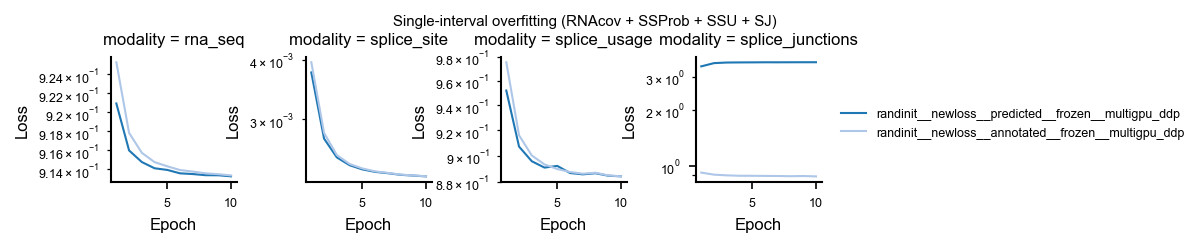

In [6]:
x = (
    X[
        ["epoch","run_name","val_loss_rna_seq_loss","val_loss_splice_site_loss","val_loss_splice_usage_loss","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name", palette="tab20",
    col="modality", col_order=PAL_MODALITIES.keys(),
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()

## performance on held-out intervals

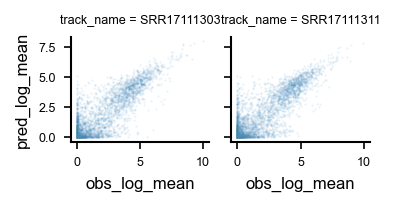

In [21]:
X = preds["rna_seq_per_gene"]

g = sns.relplot(
    kind="scatter",
    data=X,
    x="obs_log_mean",
    y="pred_log_mean",
    col="track_name",
    s=1, alpha=0.1,
    height=3.5*cm, aspect=0.9
)

g.set_titles(size=6)

plt.show()

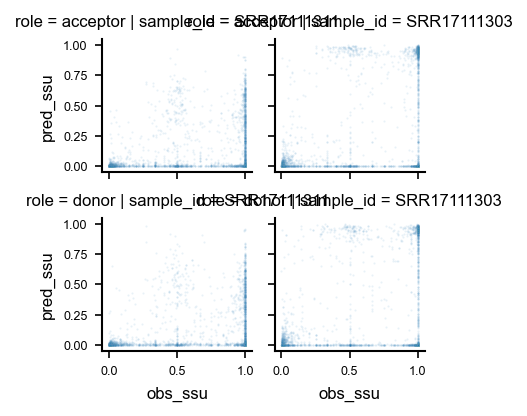

In [24]:
X = preds["ssu_scores"].sample(10000)

g = sns.relplot(
    kind="scatter",
    data=X,
    x="obs_ssu",
    y="pred_ssu",
    col="sample_id",
    row="role",
    s=1, alpha=0.1,
    height=3.5*cm, aspect=1
)

plt.show()

In [ ]:
preds.keys()

dict_keys(['rna_seq_per_gene', 'splice_site_scores', 'ssu_scores', 'junction_totals', 'junction_scores', 'psi_scores'])

In [27]:
X = preds["junction_scores"]
X

,interval_idx,chrom,donor_pos_1based,acceptor_pos_1based,strand,sample_id,pred_count,obs_count
0,0,chr20,8019226,8022381,+,SRR17111303,0.001984,0
1,0,chr20,8019226,8022557,+,SRR17111303,0.002899,0
2,0,chr20,8019226,8023271,+,SRR17111303,0.001205,0
3,0,chr20,8019226,8023337,+,SRR17111303,0.000969,0
4,0,chr20,8022155,8022381,+,SRR17111303,0.001366,1
...,...,...,...,...,...,...,...,...
110801313,6357,chr8,104531963,104499317,-,SRR17111311,0.000431,0
110801314,6357,chr8,104531963,104508939,-,SRR17111311,0.000553,0
110801315,6357,chr8,104531963,104527930,-,SRR17111311,0.000626,0
110801316,6357,chr8,104531963,104531907,-,SRR17111311,0.000668,0


In [ ]:
X = preds["junction_totals"].sample(10000)

g = sns.relplot(
    kind="scatter",
    data=X,
    x="obs_ssu",
    y="pred_ssu",
    col="sample_id",
    row="role",
    s=1, alpha=0.1,
    height=3.5*cm, aspect=1
)

plt.show()